In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False)
print(df.shape)
print(df.columns.tolist())
df.head(3)

(54081, 151)
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols = ['loan_amnt','funded_amnt','term','int_rate','installment',
        'grade','sub_grade','emp_length','home_ownership','annual_inc',
        'loan_status','purpose','dti','delinq_2yrs','fico_range_low',
        'fico_range_high','open_acc','pub_rec','revol_bal','revol_util',
        'total_acc','issue_d','earliest_cr_line','application_type']

df = df[cols].copy()

bad_statuses = ['Charged Off','Default',
                'Does not meet the credit policy. Status:Charged Off']
df['target'] = df['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)
df = df[df['loan_status'].isin(bad_statuses + ['Fully Paid'])]

print(df['target'].value_counts())
print(f"Default rate: {df['target'].mean():.2%}")

target
0    37837
1     9748
Name: count, dtype: int64
Default rate: 20.49%


In [ ]:
# int_rate and revol_util are already numeric in this version of the dataset
# Just make sure they're float
df['int_rate'] = df['int_rate'].astype(float)
df['revol_util'] = df['revol_util'].astype(float)

# Clean term
df['term'] = df['term'].str.strip().str.replace(' months','').astype(int)

# Clean emp_length
emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
           '5 years':5,'6 years':6,'7 years':7,'8 years':8,
           '9 years':9,'10+ years':10}
df['emp_length'] = df['emp_length'].map(emp_map)

# Parse dates and create vintage year
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['vintage_year'] = df['issue_d'].dt.year
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# Drop NAs in key columns
df.dropna(subset=['annual_inc','dti','revol_util','emp_length'], inplace=True)
print(df.shape)

(44539, 27)


In [ ]:
!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

df_model = pd.read_csv('loans_features.csv')
print(df_model.shape)
df_model.head()

(10285, 17)


,loan_amnt,term,int_rate,grade,annual_inc,dti,fico_avg,emp_length,revol_util,delinq_2yrs,open_acc,pub_rec,vintage_year,target,dti_quartile,fico_tier,high_risk_flag
0,15000,60,18.20,E,150000.0,0.0,762.0,2,0.0,0,4,0,2015,0.0,1.0,prime,0.0
1,18600,36,9.17,B,97000.0,0.0,772.0,2,0.0,0,7,0,2015,0.0,1.0,prime,0.0
2,2700,36,7.89,A,37000.0,0.0,787.0,1,0.0,0,4,0,2015,0.0,1.0,prime,0.0
3,4000,36,10.78,B,36000.0,0.0,732.0,2,0.0,0,5,0,2015,0.0,1.0,near_prime,0.0
4,5000,36,8.49,B,50000.0,0.0,767.0,4,0.0,0,2,0,2015,0.0,1.0,prime,0.0


In [ ]:
df_model = pd.read_csv('loans_features.csv')
print(df_model.shape)

(44417, 17)


/tmp/ipykernel_2719/1687682560.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_model = pd.read_csv('loans_features.csv')


In [ ]:
# Drop rows where target is NaN
df_model = df_model.dropna(subset=['target'])

# Also drop NaNs in features
df_model = df_model.dropna(subset=features)

print(df_model.shape)

(44416, 17)


In [ ]:
X = df_model[features]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (35532, 12), Test: (8884, 12)


In [ ]:
!pip install scorecardpy
import scorecardpy as sc

# Check Information Value of each feature
iv = sc.iv(df_model[features + ['target']], y='target')
print(iv)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=7f58eb9ed202d7c7507145686d4f1eba4d81d6f27bfd853bb680371aa5132d85
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:141: UserWarning: The positive value in "target" was replaced by 1 and negative value by 0.
  warnings.warn("The positive value in \"{}\" was replaced by 1 and negative value by 0.".format(y))


        variable  info_value
4        pub_rec    6.917162
7    delinq_2yrs    5.653667
10    annual_inc    4.915882
9      loan_amnt    4.202125
8       open_acc    3.253111
6       fico_avg    1.816562
1       int_rate    1.580856
11    emp_length    0.526640
5            dti    0.448110
3     revol_util    0.409405
0           term    0.317810
2   dti_quartile    0.000023


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Use features directly without WoE
X_tr = X_train[features_final]
X_te = X_test[features_final]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_train)

y_pred_proba = model.predict_proba(X_te_s)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.7280


In [ ]:
from scipy import stats

# Gini coefficient
gini = 2 * auc - 1
print(f"Gini coefficient: {gini:.4f}")

# KS statistic
scores_good = y_pred_proba[y_test == 0]
scores_bad = y_pred_proba[y_test == 1]
ks_stat, _ = stats.ks_2samp(scores_good, scores_bad)
print(f"KS Statistic: {ks_stat:.4f}")

Gini coefficient: 0.4560
KS Statistic: 0.3343


In [ ]:
df_test = X_test[features_final].copy()
df_test['PD'] = y_pred_proba
df_test['LGD'] = 0.45  # Industry standard for unsecured loans
df_test['EAD'] = X_test['loan_amnt'].values
df_test['Expected_Loss'] = df_test['PD'] * df_test['LGD'] * df_test['EAD']
df_test['grade'] = df_model.loc[X_test.index, 'grade'].values
df_test['vintage_year'] = df_model.loc[X_test.index, 'vintage_year'].values
df_test['actual_default'] = y_test.values

print(df_test[['PD','LGD','EAD','Expected_Loss']].describe())

                PD           LGD           EAD  Expected_Loss
count  8884.000000  8.884000e+03   8884.000000    8884.000000
mean      0.202718  4.500000e-01  14482.687978    1455.671093
std       0.144188  7.227959e-14   8629.193350    1665.594801
min       0.016505  4.500000e-01   1000.000000      19.437262
25%       0.101052  4.500000e-01   8000.000000     402.013493
50%       0.157485  4.500000e-01  12000.000000     797.714053
75%       0.262859  4.500000e-01  20000.000000    1859.693732
max       0.828656  4.500000e-01  35000.000000   12545.710310


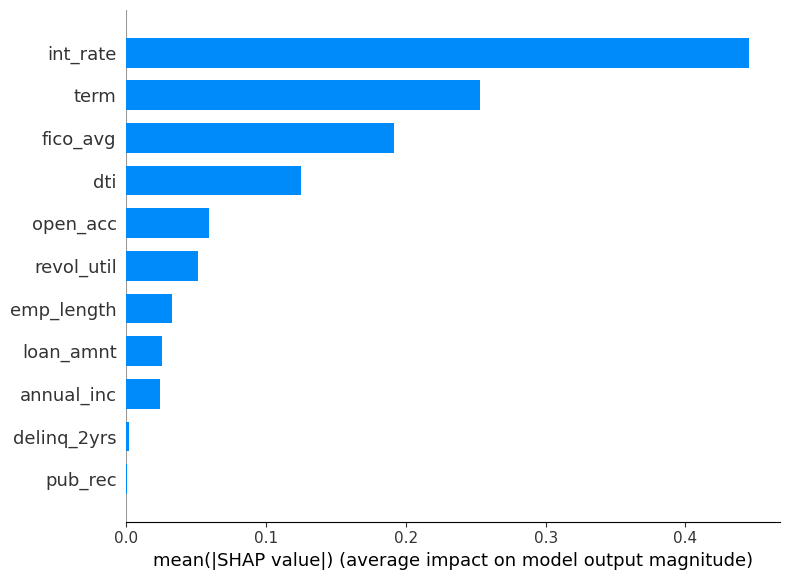

Saved!


In [ ]:
!pip install shap
import shap
import matplotlib.pyplot as plt

explainer = shap.LinearExplainer(model, X_tr_s)
shap_values = explainer.shap_values(X_te_s[:500])

shap.summary_plot(shap_values, X_test[features_final].iloc[:500],
                  feature_names=features_final,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()
print("Saved!")

In [ ]:
# Export scored data to CSV
df_test.to_csv('loans_scored.csv', index=False)

# EL by grade
el_by_grade = df_test.groupby('grade').agg(
    total_loans=('loan_amnt','count'),
    total_EAD=('EAD','sum'),
    avg_PD=('PD','mean'),
    total_EL=('Expected_Loss','sum'),
    actual_default_rate=('actual_default','mean')
).reset_index()

# EL by vintage year
el_by_vintage = df_test.groupby('vintage_year').agg(
    total_EL=('Expected_Loss','sum'),
    avg_PD=('PD','mean'),
    actual_default_rate=('actual_default','mean')
).reset_index()

el_by_grade.to_csv('el_by_grade.csv', index=False)
el_by_vintage.to_csv('el_by_vintage.csv', index=False)

print("All files saved!")
print("\nEL by Grade:")
print(el_by_grade)

All files saved!

EL by Grade:
  grade  total_loans  total_EAD    avg_PD      total_EL  actual_default_rate
0     A         1762   25620100  0.069832  8.015907e+05             0.053348
1     B         2729   34977125  0.130625  2.109320e+06             0.143276
2     C         2448   35120425  0.216593  3.605421e+06             0.220588
3     D         1139   17855550  0.332049  2.820300e+06             0.350307
4     E          574   10676950  0.460328  2.296018e+06             0.444251
5     F          189    3635375  0.625005  1.041602e+06             0.486772
6     G           43     778675  0.712851  2.579308e+05             0.534884


In [2]:
import pandas as pd

df_test = pd.read_csv('loans_scored.csv')

el_by_vintage = df_test.groupby('vintage_year').agg(
    total_EL=('Expected_Loss','sum'),
    avg_PD=('PD','mean'),
    actual_default_rate=('actual_default','mean')
).reset_index()

print(el_by_vintage)

   vintage_year      total_EL    avg_PD  actual_default_rate
0          2015  1.293218e+07  0.202718             0.201936


In [3]:
el_by_grade = df_test.groupby('grade').agg(
    total_loans=('loan_amnt','count'),
    total_EAD=('EAD','sum'),
    avg_PD=('PD','mean'),
    total_EL=('Expected_Loss','sum'),
    actual_default_rate=('actual_default','mean')
).reset_index()

el_by_grade.to_csv('el_by_grade.csv', index=False)
df_test.to_csv('loans_scored.csv', index=False)

print(el_by_grade)

  grade  total_loans  total_EAD    avg_PD      total_EL  actual_default_rate
0     A         1762   25620100  0.069832  8.015907e+05             0.053348
1     B         2729   34977125  0.130625  2.109320e+06             0.143276
2     C         2448   35120425  0.216593  3.605421e+06             0.220588
3     D         1139   17855550  0.332049  2.820300e+06             0.350307
4     E          574   10676950  0.460328  2.296018e+06             0.444251
5     F          189    3635375  0.625005  1.041602e+06             0.486772
6     G           43     778675  0.712851  2.579308e+05             0.534884
